In [4]:
import numpy as np
import pandas as pd

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
calls = pd.read_csv('calls.csv')
customers = pd.read_csv('customers.csv')
reason= pd.read_csv('reason.csv')
sentiment_statistics= pd.read_csv('sentiment_statistics.csv')
call_reason= calls.merge(reason, on ='call_id', how='left')
#converting call_time_data into date_time format 
call_reason['call_start_datetime'] = pd.to_datetime(call_reason['call_start_datetime'], errors='coerce')
call_reason['call_end_datetime'] = pd.to_datetime(call_reason['call_end_datetime'], errors='coerce')
call_reason['primary_call_reason'] = call_reason['primary_call_reason'].str.strip()
call_reason['primary_call_reason'] = (
    call_reason['primary_call_reason']
    .str.replace(r'-', '', regex=True)  # Remove hyphens
    .str.replace(r'\s+', ' ', regex=True)  # Replace multiple spaces with a single space
    .str.strip()  # Remove leading and trailing spaces
)
call_reason['primary_call_reason'] = call_reason['primary_call_reason'].str.replace(
    'Products & Services', 
    'Products and Services', 
    regex=False  # Set regex=False to treat it as a literal string
)
call_reason['primary_call_reason'] = call_reason['primary_call_reason'].str.replace(
    'PostFlight', 
    'Post Flight', 
    regex=False  # Set regex=False to treat it as a literal string
)
call_reason['HT'] = (call_reason['call_end_datetime'] - call_reason['call_start_datetime']).dt.total_seconds()

Sum_ht = call_reason.groupby('primary_call_reason')['HT'].sum().sort_values(ascending=False)
mean_ht = call_reason.groupby('primary_call_reason')['HT'].mean().sort_values(ascending=False)
call_reason['agent_assigned_datetime'] = pd.to_datetime(call_reason['agent_assigned_datetime'], errors='coerce')
call_reason['waiting_time'] = (call_reason['agent_assigned_datetime'] - call_reason['call_start_datetime']).dt.total_seconds()
call_reason['AST'] = call_reason['waiting_time'].mean()
call_reason['AHT']=call_reason['HT'].mean()
call_reason['AST'] = call_reason['waiting_time'].mean()
call_corr=call_reason.merge(sentiment_statistics,on ='call_id', how='left')

In [9]:
call_corr.head()

,call_id,customer_id,agent_id_x,call_start_datetime,agent_assigned_datetime,call_end_datetime,call_transcript,primary_call_reason,HT,waiting_time,AST,AHT,agent_id_y,agent_tone,customer_tone,average_sentiment,silence_percent_average
0,4667960400,2033123310,963118,2024-07-31 23:56:00,2024-08-01 00:03:00,2024-08-01 00:34:00,\n\nAgent: Thank you for calling United Airlin...,Voluntary Cancel,2280.0,420.0,437.067539,1134.11614,963118,neutral,angry,-0.04,0.39
1,1122072124,8186702651,519057,2024-08-01 00:03:00,2024-08-01 00:06:00,2024-08-01 00:18:00,\n\nAgent: Thank you for calling United Airlin...,Booking,900.0,180.0,437.067539,1134.11614,519057,calm,neutral,0.02,0.35
2,6834291559,2416856629,158319,2024-07-31 23:59:00,2024-08-01 00:07:00,2024-08-01 00:26:00,\n\nAgent: Thank you for calling United Airlin...,IRROPS,1620.0,480.0,437.067539,1134.11614,158319,neutral,polite,-0.13,0.32
3,2266439882,1154544516,488324,2024-08-01 00:05:00,2024-08-01 00:10:00,2024-08-01 00:17:00,\n\nAgent: Thank you for calling United Airlin...,Upgrade,720.0,300.0,437.067539,1134.11614,488324,neutral,frustrated,-0.20,0.20
4,1211603231,5214456437,721730,2024-08-01 00:04:00,2024-08-01 00:14:00,2024-08-01 00:23:00,\n\nAgent: Thank you for calling United Airlin...,Seating,1140.0,600.0,437.067539,1134.11614,721730,neutral,polite,-0.05,0.35


In [16]:
customers.head()

,customer_id,customer_name,elite_level_code
0,2033123310,Matthew Foster,4.0
1,8186702651,Tammy Walters,NaN
2,2416856629,Jeffery Dixon,NaN
3,1154544516,David Wilkins,2.0
4,5214456437,Elizabeth Daniels,0.0


In [17]:
call_cus = pd.merge(call_corr, customers, on='customer_id', how='left')

In [18]:
call_cus.head()

,call_id,customer_id,agent_id_x,call_start_datetime,agent_assigned_datetime,call_end_datetime,call_transcript,primary_call_reason,HT,waiting_time,AST,AHT,agent_id_y,agent_tone,customer_tone,average_sentiment,silence_percent_average,customer_name,elite_level_code
0,4667960400,2033123310,963118,2024-07-31 23:56:00,2024-08-01 00:03:00,2024-08-01 00:34:00,\n\nAgent: Thank you for calling United Airlin...,Voluntary Cancel,2280.0,420.0,437.067539,1134.11614,963118,neutral,angry,-0.04,0.39,Matthew Foster,4.0
1,1122072124,8186702651,519057,2024-08-01 00:03:00,2024-08-01 00:06:00,2024-08-01 00:18:00,\n\nAgent: Thank you for calling United Airlin...,Booking,900.0,180.0,437.067539,1134.11614,519057,calm,neutral,0.02,0.35,Tammy Walters,NaN
2,6834291559,2416856629,158319,2024-07-31 23:59:00,2024-08-01 00:07:00,2024-08-01 00:26:00,\n\nAgent: Thank you for calling United Airlin...,IRROPS,1620.0,480.0,437.067539,1134.11614,158319,neutral,polite,-0.13,0.32,Jeffery Dixon,NaN
3,2266439882,1154544516,488324,2024-08-01 00:05:00,2024-08-01 00:10:00,2024-08-01 00:17:00,\n\nAgent: Thank you for calling United Airlin...,Upgrade,720.0,300.0,437.067539,1134.11614,488324,neutral,frustrated,-0.20,0.20,David Wilkins,2.0
4,1211603231,5214456437,721730,2024-08-01 00:04:00,2024-08-01 00:14:00,2024-08-01 00:23:00,\n\nAgent: Thank you for calling United Airlin...,Seating,1140.0,600.0,437.067539,1134.11614,721730,neutral,polite,-0.05,0.35,Elizabeth Daniels,0.0


In [19]:
print(call_cus.columns.tolist())

['call_id', 'customer_id', 'agent_id_x', 'call_start_datetime', 'agent_assigned_datetime', 'call_end_datetime', 'call_transcript', 'primary_call_reason', 'HT', 'waiting_time', 'AST', 'AHT', 'agent_id_y', 'agent_tone', 'customer_tone', 'average_sentiment', 'silence_percent_average', 'customer_name', 'elite_level_code']


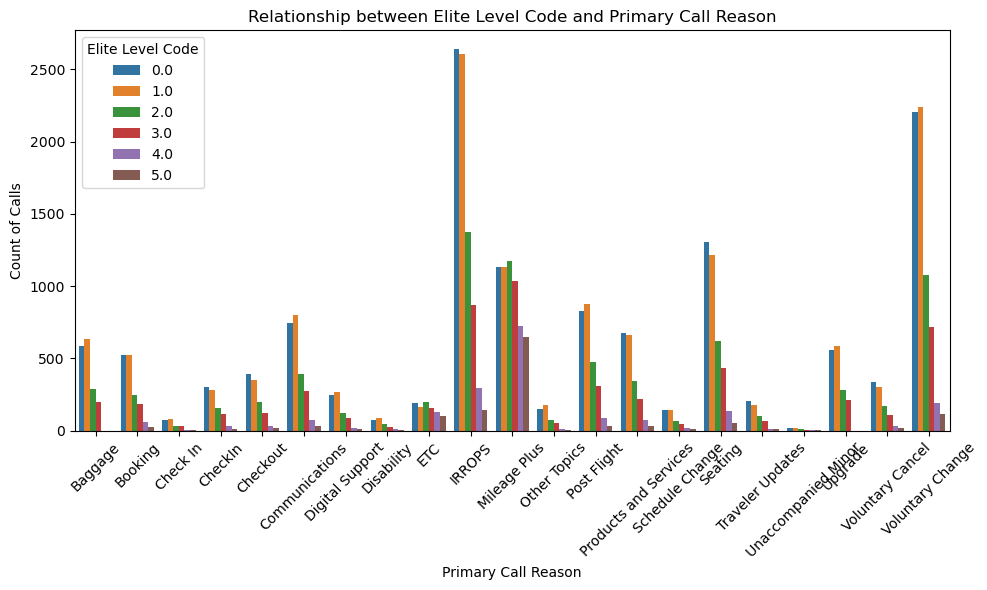

In [22]:
call_cus.dropna(subset=['elite_level_code', 'primary_call_reason'], inplace=True)
call_cus['elite_level_code'] = call_cus['elite_level_code'].astype(str)
call_cus['primary_call_reason'] = call_cus['primary_call_reason'].astype(str)






# Grouping by elite_level_code and primary_call_reason

relationship = call_cus.groupby(['elite_level_code', 'primary_call_reason']).size().reset_index(name='count')

# Set up the figure and axes
plt.figure(figsize=(10, 6))

# Create a bar plot using seaborn
sns.barplot(data=relationship, x='primary_call_reason', y='count', hue='elite_level_code')


# Add labels and title
plt.xlabel('Primary Call Reason')
plt.ylabel('Count of Calls')
plt.title('Relationship between Elite Level Code and Primary Call Reason')
plt.legend(title='Elite Level Code')
plt.xticks(rotation=45)  # Rotate x labels for better readability

# Show the plot
plt.tight_layout()  # Adjust the layout to make room for labels
plt.show()